<a href="https://colab.research.google.com/github/mjgpinheiro/Econophysics/blob/main/WDEO_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wilson–Dirac Economic Operator (WDEO)
### A Field-Theoretic Framework for Market Network Analysis

**Reference framework:**  
Adapts the Wilson–Dirac operator from lattice QFT to weighted economic networks.  
Two network types are constructed from real market data:
- **Symmetric W** — undirected: $W_{ij} = |\text{corr}(r_i, r_j)|$
- **Directed W** — lead-lag: $W_{ij} = \text{corr}(r_i(t),\, r_j(t-1))$

**Operator decomposition:**
$$D_{\text{WDE}} = \underbrace{\frac{W - W^T}{2}}_{\text{Dirac term (transport)}} - \frac{r}{2}\underbrace{\left(D_{\deg} - \frac{W+W^T}{2}\right)}_{\text{Wilson term (regularisation)}}$$

**Ergontropic functional:**  
$$\mathcal{E}_i = \Psi_i^\dagger\, D_{\text{WDE}}\, \Psi_i$$

---
**Assets:** SPY, QQQ, IWM, XLF, XLK, XLE, XLV, XLI, TLT, GLD, ^VIX, USO, BTC-USD, ETH-USD  
**Period:** 2017–2024  
**Crisis benchmarks:** Q4-2018, COVID-2020, Bear-2022

## 0. Install & Imports

In [1]:
!pip install yfinance scipy numpy pandas matplotlib -q

In [2]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'figure.dpi': 130,
})
print('Ready.')

Ready.


## 1. Configuration
Edit tickers, dates, and Wilson strength here.

In [3]:
# ── Asset universe ──────────────────────────────────────────────────────────
TICKERS = [
    'SPY', 'QQQ', 'IWM',          # broad equity
    'XLF', 'XLK', 'XLE', 'XLV', 'XLI',  # sectors
    'TLT', 'GLD',                  # safe havens
    '^VIX',                        # fear gauge
    'USO',                         # oil
    'BTC-USD', 'ETH-USD',          # crypto
]

START_DATE = '2017-01-01'
END_DATE   = '2024-12-31'

# ── Rolling window parameters ───────────────────────────────────────────────
WINDOW = 40    # trading days per snapshot
STEP   = 5     # days between snapshots

# ── Wilson strength ─────────────────────────────────────────────────────────
R_DEFAULT = 1.0   # increase → more regularisation

# ── Known crisis windows (for overlay) ─────────────────────────────────────
CRISIS_PERIODS = [
    ('2018-10-01', '2018-12-24', 'Q4-2018'),
    ('2020-02-19', '2020-03-23', 'COVID-2020'),
    ('2022-01-03', '2022-10-13', 'Bear-2022'),
]

print('Config loaded.')

Config loaded.


## 2. Download Data

In [4]:
print(f'Downloading {len(TICKERS)} tickers from Yahoo Finance...')
raw = yf.download(TICKERS, start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=True)['Close']

# Drop columns with more than 15% missing values
raw = raw.dropna(axis=1, thresh=int(0.85 * len(raw)))

# Log returns
returns = np.log(raw / raw.shift(1)).dropna()

ASSETS = list(returns.columns)
N = len(ASSETS)

print(f'\nAssets ({N}): {ASSETS}')
print(f'Period:  {returns.index[0].date()} → {returns.index[-1].date()}')
print(f'Trading days: {len(returns)}')
returns.describe().round(4)

[*********************100%***********************]  14 of 14 completed



Assets (2): ['BTC-USD', 'ETH-USD']
Period:  2017-11-10 → 2024-12-30
Trading days: 2608


Ticker,BTC-USD,ETH-USD
count,2608.0000,2608.0000
mean,0.0010,0.0009
std,0.0367,0.0463
min,-0.4647,-0.5507
25%,-0.0140,-0.0187
50%,0.0009,0.0008
75%,0.0165,0.0222
max,0.2251,0.2347


## 3. Build Rolling Network Snapshots

In [5]:
def build_symmetric_W(chunk: pd.DataFrame) -> np.ndarray:
    """
    Undirected weight matrix: W_ij = |corr(r_i, r_j)|, diagonal = 0.
    This makes D_econ = (W - W^T)/2 = 0, so WDEO = Wilson term only.
    """
    W = np.abs(chunk.corr().fillna(0).values)
    np.fill_diagonal(W, 0.0)
    return W


def build_directed_W(chunk: pd.DataFrame) -> np.ndarray:
    """
    Directed weight matrix: W_ij = corr(r_i(t), r_j(t-1)).
    Row i, col j = how strongly j yesterday predicts i today.
    Asymmetric → non-trivial Dirac term.
    """
    today = chunk.values[1:]
    yest  = chunk.values[:-1]
    n_a   = today.shape[1]
    W = np.zeros((n_a, n_a))
    for i in range(n_a):
        for j in range(n_a):
            if i != j:
                c = np.corrcoef(today[:, i], yest[:, j])[0, 1]
                W[i, j] = c if np.isfinite(c) else 0.0
    return W


print('Building rolling network snapshots...')
dates_list, sym_mats, dir_mats = [], [], []
T = len(returns)

for start in range(0, T - WINDOW, STEP):
    chunk = returns.iloc[start:start + WINDOW]
    dates_list.append(returns.index[start + WINDOW - 1])
    sym_mats.append(build_symmetric_W(chunk))
    dir_mats.append(build_directed_W(chunk))

n_win = len(dates_list)
print(f'Done. {n_win} network snapshots generated.')

Building rolling network snapshots...
Done. 514 network snapshots generated.


## 4. WDEO Operator

In [6]:
def dirac_term(W: np.ndarray) -> np.ndarray:
    """Antisymmetric transport: (W - W^T) / 2."""
    return (W - W.T) / 2.0


def wilson_laplacian(W: np.ndarray) -> np.ndarray:
    """Symmetric graph Laplacian: D_deg - W_sym."""
    W_sym = (W + W.T) / 2.0
    return np.diag(W_sym.sum(axis=1)) - W_sym


def wdeo(W: np.ndarray, r: float = 1.0) -> np.ndarray:
    """Full Wilson-Dirac Economic Operator."""
    return dirac_term(W) - (r / 2.0) * wilson_laplacian(W)


# ── Scalar observables ───────────────────────────────────────────────────────

def operator_norm(W, r=1.0):
    """Frobenius norm of WDEO — overall structural stress."""
    return float(np.linalg.norm(wdeo(W, r), 'fro'))


def spectral_gap(W, r=1.0):
    """Gap between two largest real parts of eigenvalues."""
    ev = np.sort(np.real(la.eigvals(wdeo(W, r))))[::-1]
    return float(ev[0] - ev[1]) if len(ev) > 1 else 0.0


def directed_flow_intensity(W):
    """‖D_econ‖ / ‖W‖ — fraction of network that is directional."""
    d = np.linalg.norm(dirac_term(W), 'fro')
    w = np.linalg.norm(W, 'fro')
    return float(d / (w + 1e-12))


def ergontropy(W, r=1.0):
    """Per-node ergontropic functional E_i = Psi_i† D_WDE Psi_i."""
    M = wdeo(W, r)
    ev, vec = la.eig(M)
    idx = np.argmax(np.real(ev))
    Psi = vec[:, idx]
    return np.real(np.conj(Psi) * (M @ Psi))


print('Operators defined.')

# Quick sanity check on one snapshot
M_test = wdeo(sym_mats[0], r=R_DEFAULT)
print(f'Shape: {M_test.shape}  |  '
      f'‖D_WDE‖_F = {np.linalg.norm(M_test, "fro"):.4f}  |  '
      f'max Re(λ) = {np.max(np.real(la.eigvals(M_test))):.4f}')

Operators defined.
Shape: (2, 2)  |  ‖D_WDE‖_F = 0.0639  |  max Re(λ) = 0.0000


## 5. Compute Signals Over Time

In [7]:
print('Computing signals (this takes ~1 min for directed W)...')

r_scan = [0.5, 1.0, 2.0]

# Operator norms
sym_norms = {r: np.array([operator_norm(W, r) for W in sym_mats]) for r in r_scan}
dir_norms = {r: np.array([operator_norm(W, r) for W in dir_mats]) for r in r_scan}

# Spectral gap (directed, r=1)
sp_gap = np.array([spectral_gap(W, R_DEFAULT) for W in dir_mats])

# Directed flow intensity
dfi = np.array([directed_flow_intensity(W) for W in dir_mats])

# Ergontropy matrix (directed, r=1)
ergo_matrix = np.zeros((n_win, N))
for t, W in enumerate(dir_mats):
    try:
        ergo_matrix[t] = ergontropy(W, R_DEFAULT)
    except Exception:
        pass

print('Done.')

Computing signals (this takes ~1 min for directed W)...
Done.


## 6. Crisis Period Helper

In [8]:
date_arr = pd.to_datetime(dates_list)

def shade_crises(ax):
    """Shade known crisis windows on a time-series axis."""
    ylim = ax.get_ylim()
    for s, e, label in CRISIS_PERIODS:
        sd, ed = pd.Timestamp(s), pd.Timestamp(e)
        mask = (date_arr >= sd) & (date_arr <= ed)
        idxs = np.where(mask)[0]
        if len(idxs) > 0:
            ax.axvspan(idxs[0], idxs[-1], alpha=0.13, color='red', zorder=0)
            ax.text((idxs[0] + idxs[-1]) // 2, ylim[1] * 0.95, label,
                    ha='center', va='top', fontsize=7.5, color='darkred')


def xticks(ax):
    """Readable date labels on x-axis."""
    ts = max(1, n_win // 10)
    tp = list(range(0, n_win, ts))
    ax.set_xticks(tp)
    ax.set_xticklabels([str(dates_list[i])[:10] for i in tp],
                       rotation=35, ha='right', fontsize=8)


def get_crisis_mask():
    ci = set()
    for s, e, _ in CRISIS_PERIODS:
        sd, ed = pd.Timestamp(s), pd.Timestamp(e)
        idxs = np.where((date_arr >= sd) & (date_arr <= ed))[0]
        ci.update(idxs.tolist())
    return np.array(sorted(ci)), np.array(sorted(set(range(n_win)) - ci))

crisis_idx, calm_idx = get_crisis_mask()
print(f'Crisis windows: {len(crisis_idx)} snapshots  |  Calm: {len(calm_idx)} snapshots')

Crisis windows: 80 snapshots  |  Calm: 434 snapshots


## 7. Figure 1 — Main Signal (4 panels)

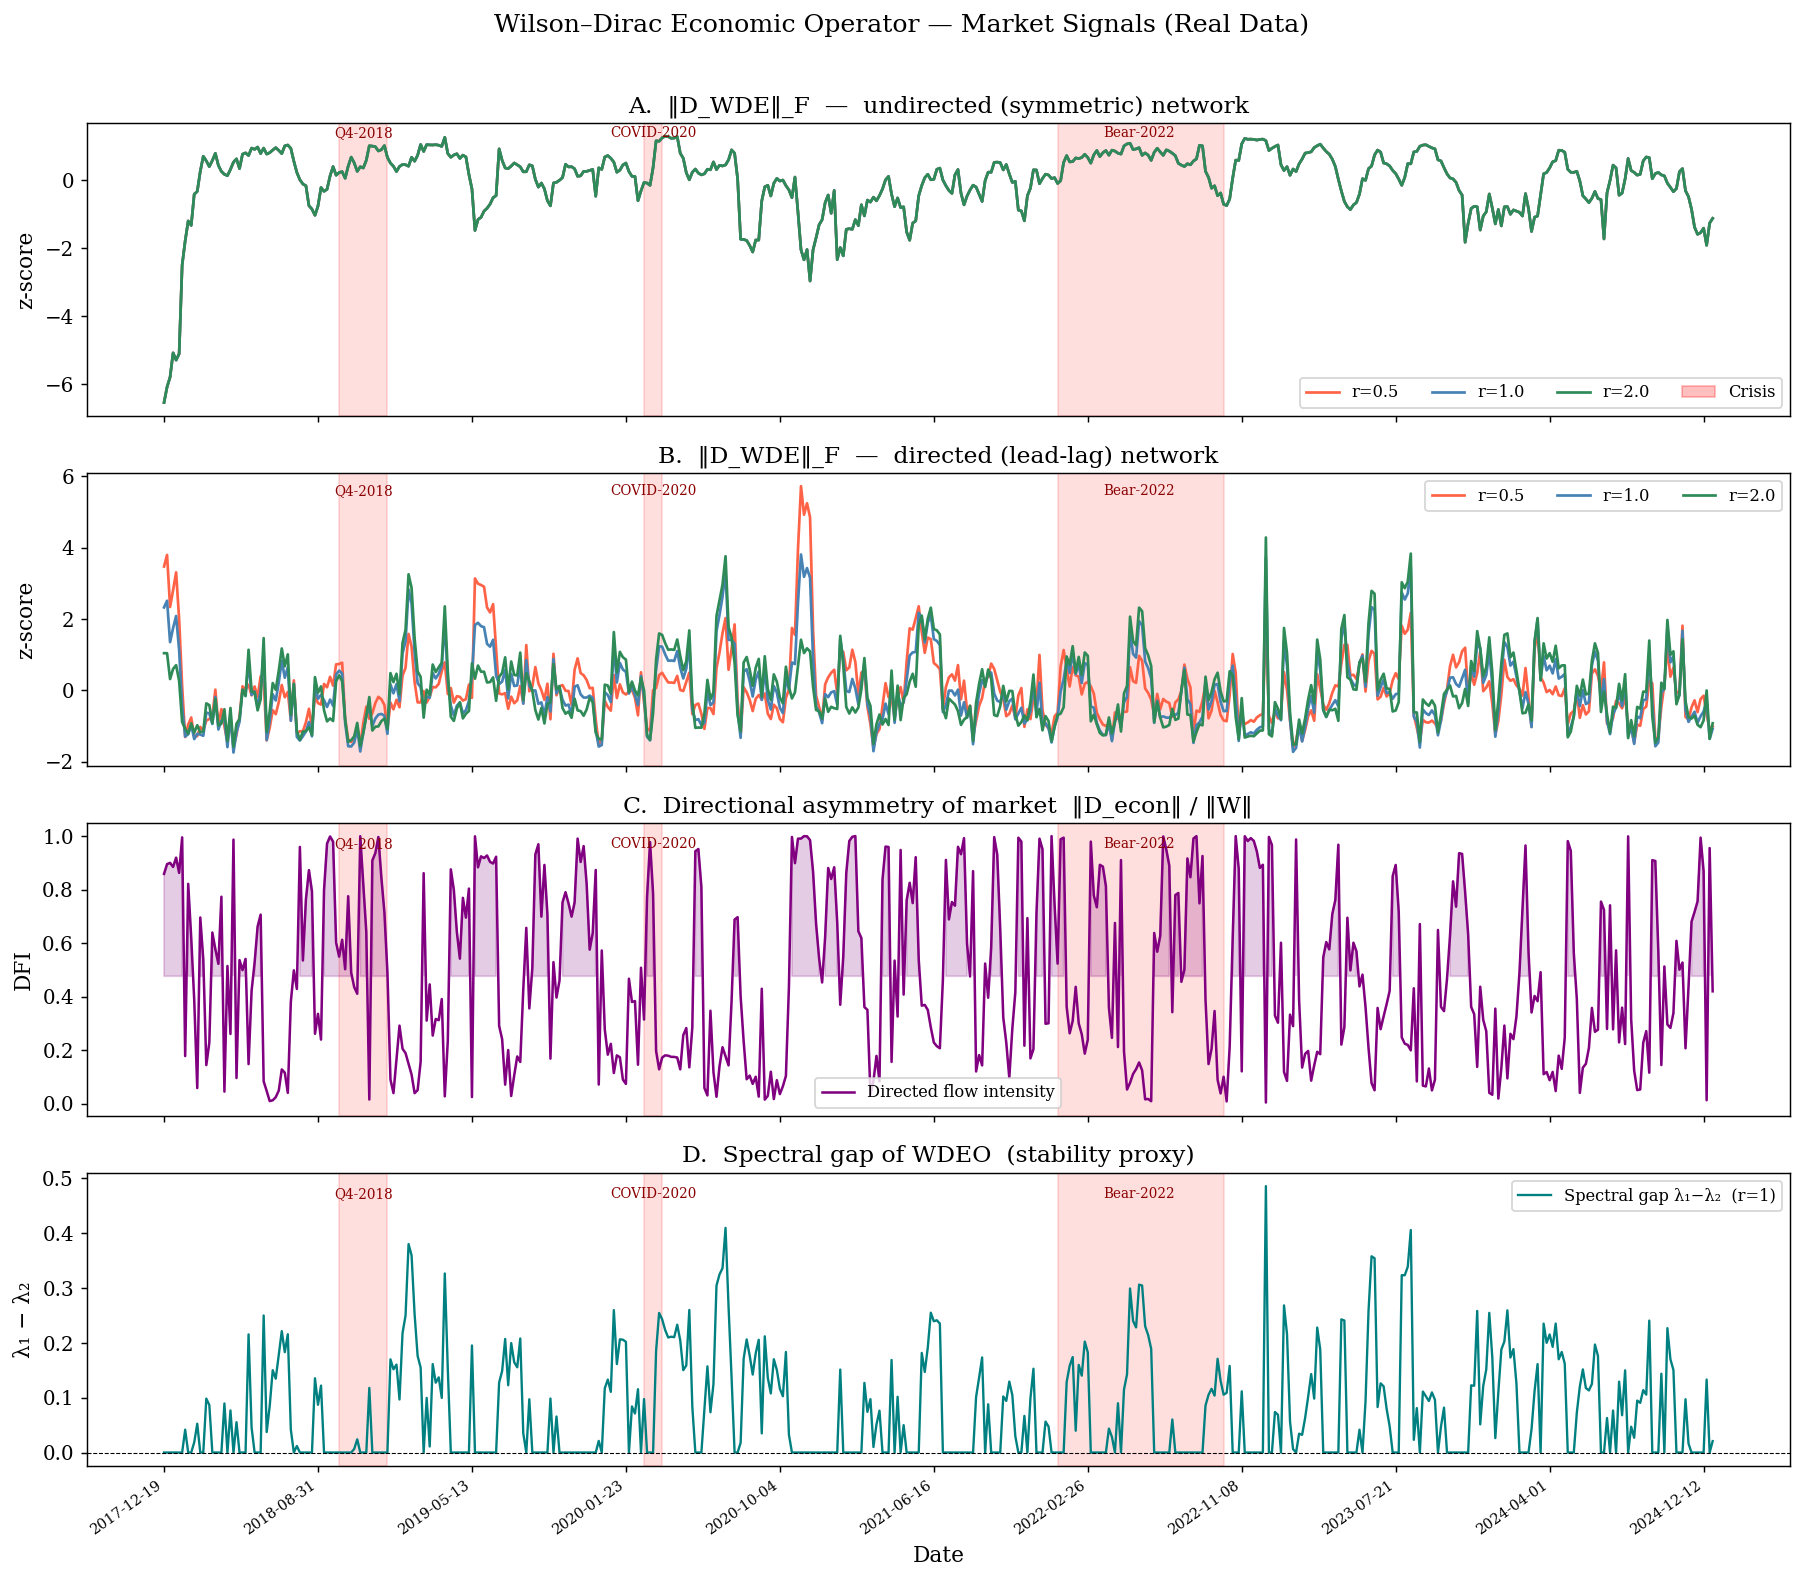

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
colors = ['tomato', 'steelblue', 'seagreen']

# Panel A: Symmetric W norm
ax = axes[0]
for r, c in zip(r_scan, colors):
    s = sym_norms[r]
    ax.plot((s - s.mean()) / s.std(), color=c, lw=1.5, label=f'r={r}')
ax.set_ylabel('z-score')
ax.set_title('A.  ‖D_WDE‖_F  —  undirected (symmetric) network')
ax.set_ylim(ax.get_ylim()); shade_crises(ax); ax.legend(fontsize=9, ncol=3)

# Panel B: Directed W norm
ax = axes[1]
for r, c in zip(r_scan, colors):
    s = dir_norms[r]
    ax.plot((s - s.mean()) / s.std(), color=c, lw=1.5, label=f'r={r}')
ax.set_ylabel('z-score')
ax.set_title('B.  ‖D_WDE‖_F  —  directed (lead-lag) network')
ax.set_ylim(ax.get_ylim()); shade_crises(ax); ax.legend(fontsize=9, ncol=3)

# Panel C: Directed flow intensity
ax = axes[2]
ax.plot(dfi, color='purple', lw=1.4, label='Directed flow intensity')
ax.fill_between(range(n_win), dfi.mean(), dfi,
                where=dfi > dfi.mean(), alpha=0.2, color='purple')
ax.set_ylabel('DFI')
ax.set_title('C.  Directional asymmetry of market  ‖D_econ‖ / ‖W‖')
ax.set_ylim(ax.get_ylim()); shade_crises(ax); ax.legend(fontsize=9)

# Panel D: Spectral gap
ax = axes[3]
ax.plot(sp_gap, color='teal', lw=1.3, label='Spectral gap λ₁−λ₂  (r=1)')
ax.axhline(0, color='black', lw=0.6, ls='--')
ax.set_ylabel('λ₁ − λ₂')
ax.set_title('D.  Spectral gap of WDEO  (stability proxy)')
ax.set_ylim(ax.get_ylim()); shade_crises(ax); ax.legend(fontsize=9)
xticks(ax)
ax.set_xlabel('Date')

red_p = mpatches.Patch(color='red', alpha=0.25, label='Crisis window')
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles + [red_p], labels + ['Crisis'], fontsize=9, ncol=4)

fig.suptitle('Wilson–Dirac Economic Operator — Market Signals (Real Data)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('wdeo_fig1_signal.pdf', bbox_inches='tight')
plt.show()

## 8. Figure 2 — Crisis Discrimination

Computing Cohen's d curves...


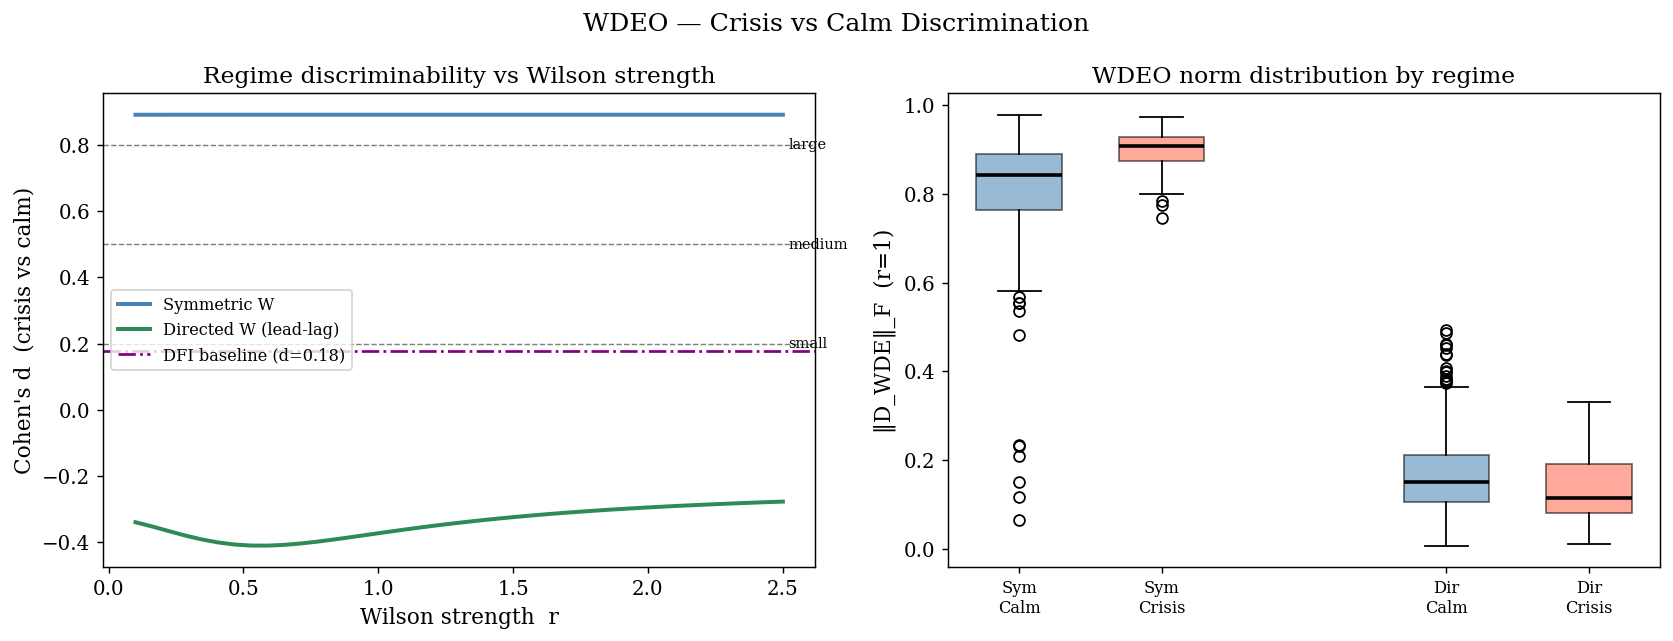


Cohen's d at r=1.0:
  Symmetric W: 0.891
  Directed W:  -0.370
  DFI baseline: 0.179


In [10]:
r_range = np.linspace(0.1, 2.5, 40)

def cohens_d_vs_r(mats):
    ds = []
    for r in r_range:
        norms = np.array([operator_norm(W, r) for W in mats])
        mc = norms[crisis_idx].mean()
        mn = norms[calm_idx].mean()
        sp = np.sqrt((norms[crisis_idx].var() + norms[calm_idx].var()) / 2 + 1e-8)
        ds.append((mc - mn) / sp)
    return np.array(ds)

print('Computing Cohen\'s d curves...')
d_sym = cohens_d_vs_r(sym_mats)
d_dir = cohens_d_vs_r(dir_mats)

# DFI baseline (independent of r)
dfi_d = (dfi[crisis_idx].mean() - dfi[calm_idx].mean()) / \
        np.sqrt((dfi[crisis_idx].var() + dfi[calm_idx].var()) / 2 + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Cohen's d vs r
ax = axes[0]
ax.plot(r_range, d_sym, color='steelblue', lw=2.2, label='Symmetric W')
ax.plot(r_range, d_dir, color='seagreen',  lw=2.2, label='Directed W (lead-lag)')
ax.axhline(dfi_d, color='purple', lw=1.5, ls='-.', label=f'DFI baseline (d={dfi_d:.2f})')
for level, label in [(0.2,'small'), (0.5,'medium'), (0.8,'large')]:
    ax.axhline(level, color='gray', lw=0.8, ls='--')
    ax.text(r_range[-1] + 0.02, level, label, fontsize=8, va='center')
ax.set_xlabel('Wilson strength  r')
ax.set_ylabel("Cohen's d  (crisis vs calm)")
ax.set_title('Regime discriminability vs Wilson strength')
ax.legend(fontsize=9)

# Box plot
ax = axes[1]
data_boxes = [
    sym_norms[1.0][calm_idx],
    sym_norms[1.0][crisis_idx],
    dir_norms[1.0][calm_idx],
    dir_norms[1.0][crisis_idx],
]
bp = ax.boxplot(data_boxes, positions=[0,1,3,4], widths=0.6,
                patch_artist=True,
                medianprops=dict(color='black', lw=2))
fill_colors = ['steelblue','tomato','steelblue','tomato']
for patch, c in zip(bp['boxes'], fill_colors):
    patch.set_facecolor(c); patch.set_alpha(0.55)
ax.set_xticks([0, 1, 3, 4])
ax.set_xticklabels(['Sym\nCalm', 'Sym\nCrisis', 'Dir\nCalm', 'Dir\nCrisis'], fontsize=9)
ax.set_ylabel('‖D_WDE‖_F  (r=1)')
ax.set_title('WDEO norm distribution by regime')

fig.suptitle('WDEO — Crisis vs Calm Discrimination', fontsize=14)
plt.tight_layout()
plt.savefig('wdeo_fig2_discrimination.pdf', bbox_inches='tight')
plt.show()

print(f"\nCohen's d at r=1.0:")
print(f'  Symmetric W: {d_sym[np.argmin(np.abs(r_range - 1.0))]:.3f}')
print(f'  Directed W:  {d_dir[np.argmin(np.abs(r_range - 1.0))]:.3f}')
print(f'  DFI baseline: {dfi_d:.3f}')

## 9. Figure 3 — Ergontropic Map

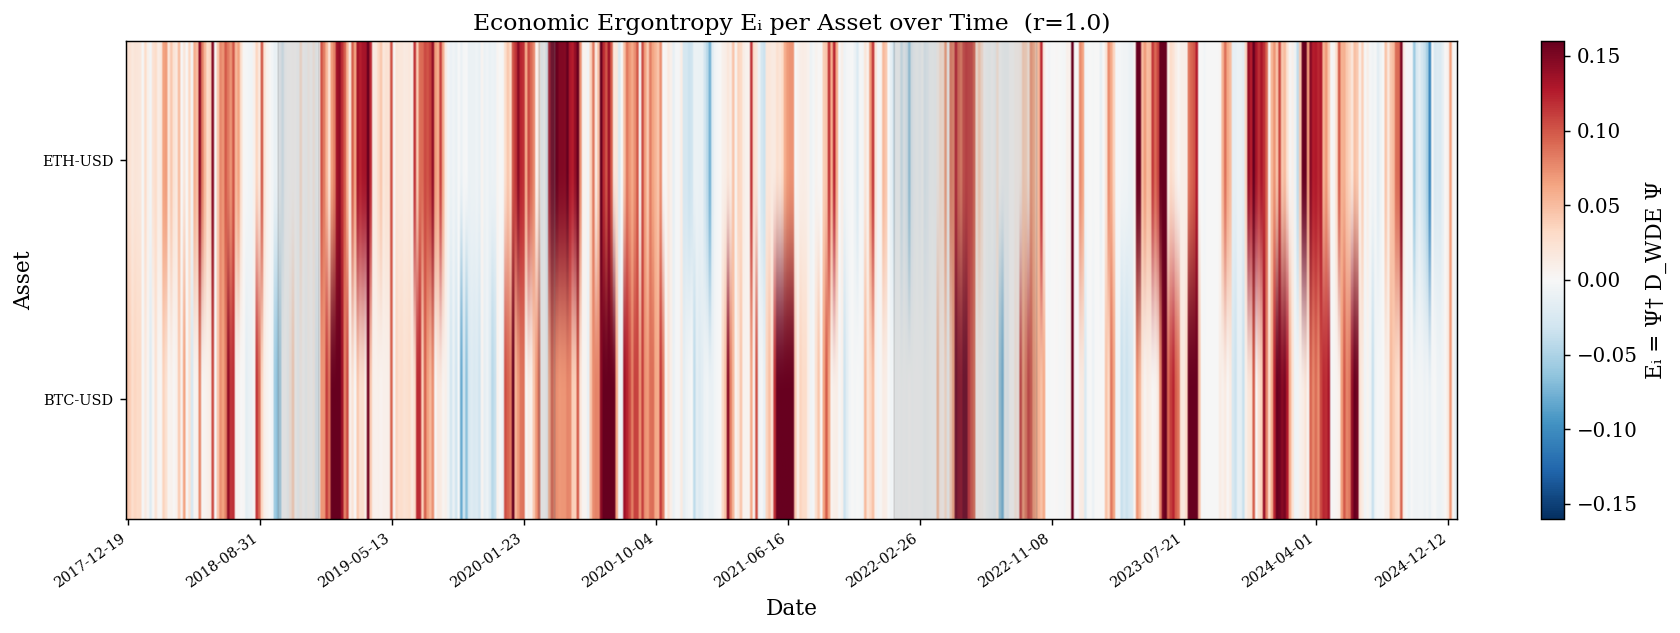

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))
lim = np.percentile(np.abs(ergo_matrix), 96)
im  = ax.imshow(ergo_matrix.T, aspect='auto', cmap='RdBu_r',
                origin='lower', vmin=-lim, vmax=lim)
ax.set_yticks(range(N))
ax.set_yticklabels(ASSETS, fontsize=8)
xticks(ax)
ax.set_xlabel('Date'); ax.set_ylabel('Asset')
plt.colorbar(im, ax=ax, label='Eᵢ = Ψ† D_WDE Ψ')
ax.set_title(f'Economic Ergontropy Eᵢ per Asset over Time  (r={R_DEFAULT})',
             fontsize=13)

# Crisis shading
for s, e, _ in CRISIS_PERIODS:
    mask = (date_arr >= pd.Timestamp(s)) & (date_arr <= pd.Timestamp(e))
    idxs = np.where(mask)[0]
    if len(idxs) > 0:
        ax.axvspan(idxs[0], idxs[-1], alpha=0.18, color='gray')

plt.tight_layout()
plt.savefig('wdeo_fig3_ergontropy.pdf', bbox_inches='tight')
plt.show()

## 10. Figure 4 — Spectral Portrait (Calm vs Crisis)

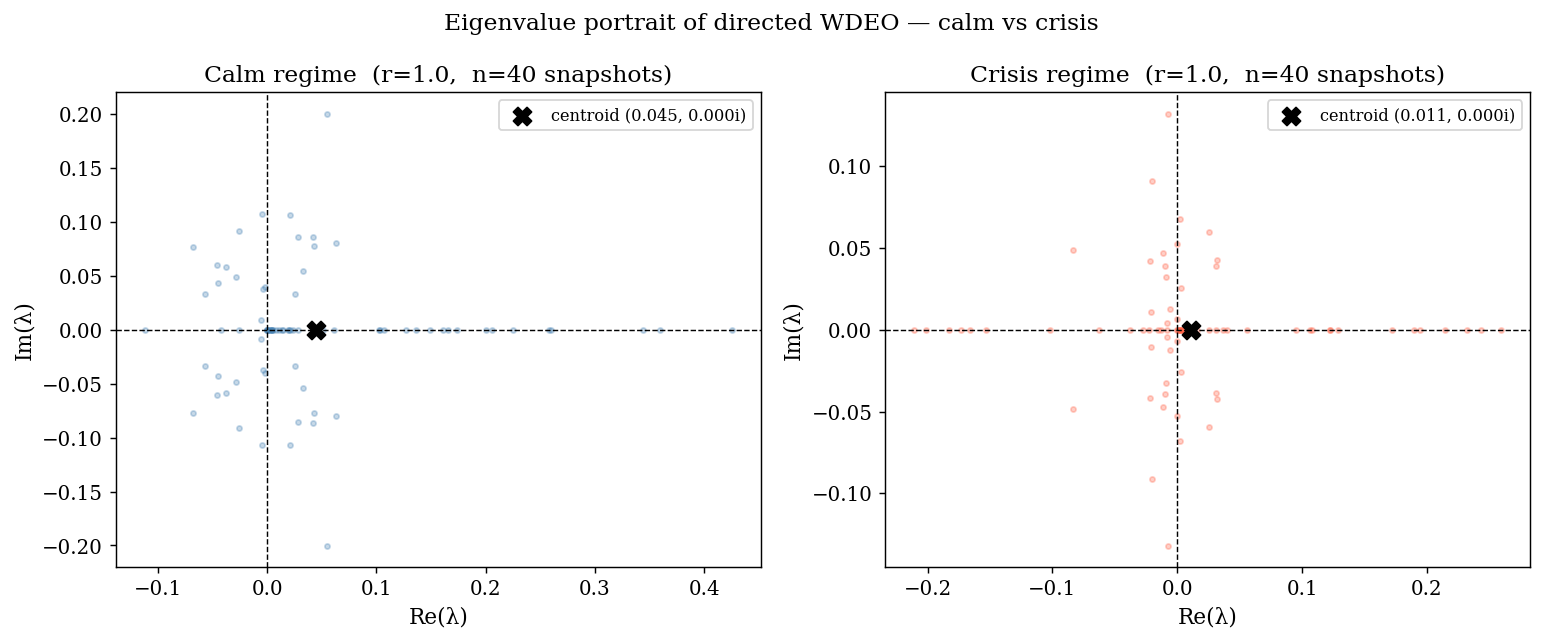

In [12]:
rng = np.random.default_rng(42)
n_sample = min(40, len(crisis_idx), len(calm_idx))
ci_s   = rng.choice(crisis_idx, n_sample, replace=False)
calm_s = rng.choice(calm_idx,   n_sample, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, idx_set, label, c in [
    (axes[0], calm_s,  'Calm',   'steelblue'),
    (axes[1], ci_s,    'Crisis', 'tomato'),
]:
    all_ev = []
    for idx in idx_set:
        M = wdeo(dir_mats[idx], R_DEFAULT)
        all_ev.extend(la.eigvals(M).tolist())
    all_ev = np.array(all_ev)
    ax.scatter(np.real(all_ev), np.imag(all_ev), s=8, alpha=0.3, color=c)
    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.axhline(0, color='black', lw=0.8, ls='--')
    cx, cy = np.real(all_ev).mean(), np.imag(all_ev).mean()
    ax.scatter([cx], [cy], s=100, color='black', marker='X',
               zorder=5, label=f'centroid ({cx:.3f}, {cy:.3f}i)')
    ax.set_xlabel('Re(λ)'); ax.set_ylabel('Im(λ)')
    ax.set_title(f'{label} regime  (r={R_DEFAULT},  n={n_sample} snapshots)')
    ax.legend(fontsize=9)

fig.suptitle('Eigenvalue portrait of directed WDEO — calm vs crisis', fontsize=13)
plt.tight_layout()
plt.savefig('wdeo_fig4_spectral_portrait.pdf', bbox_inches='tight')
plt.show()

## 11. Figure 5 — Network Anatomy (Calm vs Crisis)

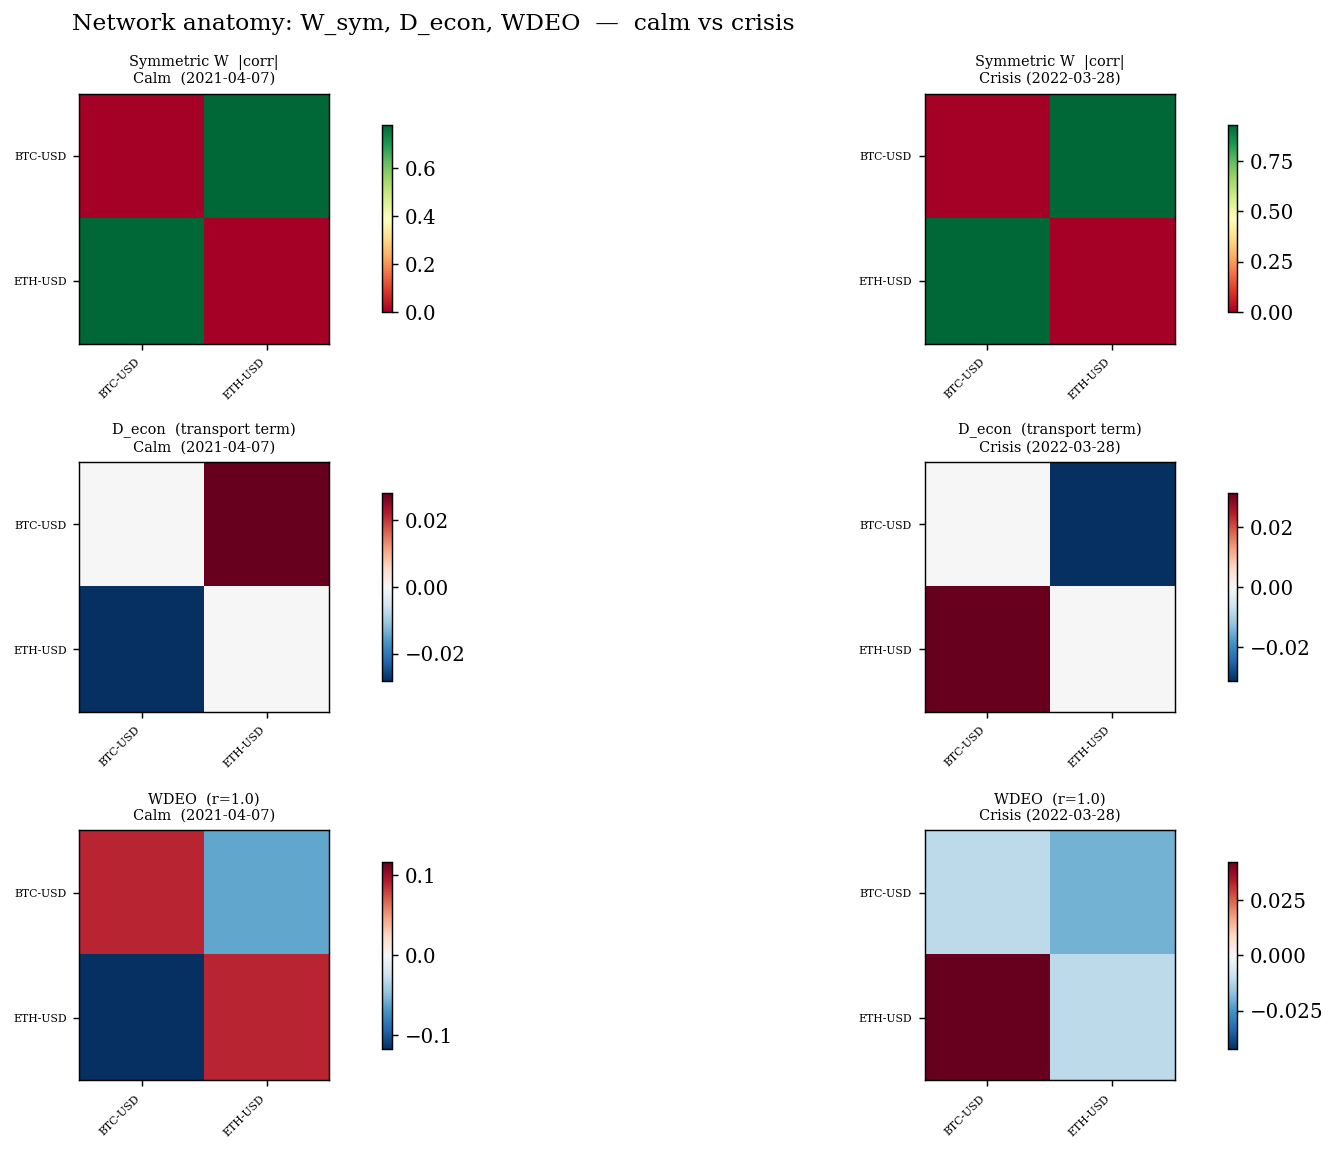

In [14]:
# Find representative calm and crisis snapshot indices
calm_mid_idx  = calm_idx[len(calm_idx) // 2]
crisis_mid_idx = crisis_idx[len(crisis_idx) // 2]

fig, axes = plt.subplots(3, 2, figsize=(15, 9)) # Changed from (2, 3) to (3, 2)

for col, (snap_idx, period_label) in enumerate([
    (calm_mid_idx,   f'Calm  ({str(dates_list[calm_mid_idx])[:10]})'),
    (crisis_mid_idx, f'Crisis ({str(dates_list[crisis_mid_idx])[:10]})'),
]):
    W_s = sym_mats[snap_idx]
    W_d = dir_mats[snap_idx]
    M   = wdeo(W_d, R_DEFAULT)

    for row, (mat, title) in enumerate([
        (W_s,            'Symmetric W  |corr|'),
        (dirac_term(W_d), 'D_econ  (transport term)'),
        (M,               f'WDEO  (r={R_DEFAULT})'),
    ]):
        ax = axes[row][col]
        lim = np.abs(mat).max()
        cmap = 'RdBu_r' if mat.min() < 0 else 'RdYlGn'
        vmin = -lim if mat.min() < 0 else 0
        im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=lim)
        ax.set_title(f'{title}\n{period_label}', fontsize=8)
        ax.set_xticks(range(N))
        ax.set_xticklabels(ASSETS, rotation=45, ha='right', fontsize=6)
        ax.set_yticks(range(N))
        ax.set_yticklabels(ASSETS, fontsize=6)
        plt.colorbar(im, ax=ax, shrink=0.75)

fig.suptitle('Network anatomy: W_sym, D_econ, WDEO  —  calm vs crisis', fontsize=13)
plt.tight_layout()
plt.savefig('wdeo_fig5_anatomy.pdf', bbox_inches='tight')
plt.show()

## 12. Summary Statistics

In [ ]:
print('=' * 55)
print('WDEO — Summary Statistics on Real Market Data')
print('=' * 55)
print(f'Assets:   {N}  |  Snapshots: {n_win}')
print(f'Crisis:   {len(crisis_idx)} snapshots  |  Calm: {len(calm_idx)} snapshots')
print()

for label, mats in [('Symmetric W', sym_mats), ('Directed W', dir_mats)]:
    print(f'  {label}:')
    for r in [0.5, 1.0, 2.0]:
        norms = np.array([operator_norm(W, r) for W in mats])
        mc = norms[crisis_idx].mean()
        mn = norms[calm_idx].mean()
        sp = np.sqrt((norms[crisis_idx].var() + norms[calm_idx].var()) / 2 + 1e-8)
        d  = (mc - mn) / sp
        print(f"    r={r:.1f}: crisis/calm={mc/mn:.3f}  Cohen's d={d:.3f}")
    print()

dc = dfi[crisis_idx]; dn = dfi[calm_idx]
sp = np.sqrt((dc.var() + dn.var()) / 2 + 1e-8)
print(f"  Directed Flow Intensity: crisis/calm={dc.mean()/dn.mean():.3f}  "
      f"Cohen's d={(dc.mean()-dn.mean())/sp:.3f}")

print()
print('Saved PDFs: wdeo_fig1_signal.pdf … wdeo_fig5_anatomy.pdf')

---
## Appendix: Key Equations

### Operator decomposition
$$D_{\text{WDE}}(W, r) = \underbrace{\frac{W - W^T}{2}}_{D_{\text{econ}} \;\text{(Dirac)}} \;-\; \frac{r}{2}\underbrace{\left(\text{diag}\left(\frac{W+W^T}{2}\mathbf{1}\right) - \frac{W+W^T}{2}\right)}_{L_{\text{sym}} \;\text{(Wilson/Laplacian)}}$$

### Weight matrices
| Type | Definition | Structure |
|---|---|---|
| Symmetric | $W_{ij} = |\text{corr}(r_i(t), r_j(t))|$ | $W = W^T$ → $D_{\text{econ}} = 0$ |
| Directed | $W_{ij} = \text{corr}(r_i(t), r_j(t-1))$ | $W \neq W^T$ → $D_{\text{econ}} \neq 0$ |

### Ergontropic functional
$$\mathcal{E}_i = \Psi_i^\dagger\, D_{\text{WDE}}\, \Psi_i \qquad \text{where } \Psi \text{ = dominant eigenvector}$$

Measures the *local capacity for extractable structural reorganisation* at node $i$.

### Regime discrimination
$$d = \frac{\mu_{\text{crisis}} - \mu_{\text{calm}}}{\sigma_{\text{pooled}}} \qquad \text{(Cohen's d)}$$

$d > 0.8$ = large effect (standard threshold for publication-quality discrimination).